# ListenBrainz Star Schema Business Analysis Notebook

This notebook retrieves answers for six business questions from the ListenBrainz star schema in Google BigQuery.

## Business Questions

1. Which artists are most listened to?
2. Which songs are most popular?
3. What time of day do users listen most?
4. How does listening change monthly?
5. Which users listen most often?
6. Which albums/releases are trending?

## BigQuery Dataset

`my-project-sssint1.listenbrainz_gcp`


## 1. Install required packages

Run this cell if the packages are not already installed.


In [1]:
!pip install google-cloud-bigquery pandas db-dtypes matplotlib


## 2. Setup BigQuery connection

Update the service account key path if your file is stored in a different location.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
from pathlib import Path

import pandas as pd
from google.cloud import bigquery
import matplotlib.pyplot as plt

SERVICE_ACCOUNT_KEY_PATH = "/content/drive/MyDrive/keys/my-project-sssint1-7e02e9078e06.json"

PROJECT_ID = "my-project-sssint1"
DATASET = "listenbrainz_gcp"

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_KEY_PATH

client = bigquery.Client(project=PROJECT_ID)

OUTPUT_DIR = Path("listenbrainz_analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Project:", PROJECT_ID)
print("Dataset:", DATASET)
print("Output folder:", OUTPUT_DIR.resolve())


Project: my-project-sssint1
Dataset: listenbrainz_gcp
Output folder: /content/listenbrainz_analysis_outputs


## 3. Helper function to run queries and export results


In [8]:
def run_query(query_name: str, sql: str) -> pd.DataFrame:
    """Run a BigQuery SQL query, save the result to CSV, and return a DataFrame."""
    print(f"Running query: {query_name}")
    df = client.query(sql).to_dataframe()

    output_path = OUTPUT_DIR / f"{query_name}.csv"
    df.to_csv(output_path, index=False)

    print(f"Saved: {output_path}")
    return df


## 4. Which artists are most listened to?

Tables used: `fact_listening_events`, `dim_artist`


In [9]:
query_top_artists = f"""
SELECT
    ar.artist_name,
    COUNT(*) AS total_listens
FROM `{PROJECT_ID}.{DATASET}.fact_listening_events` f
LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_artist` ar
    ON f.artist_id = ar.artist_id
WHERE ar.artist_name IS NOT NULL
GROUP BY ar.artist_name
ORDER BY total_listens DESC
LIMIT 10
"""

top_artists = run_query("top_artists", query_top_artists)
top_artists


Running query: top_artists
Saved: listenbrainz_analysis_outputs/top_artists.csv


,artist_name,total_listens
0,The Beatles,59702964
1,Pearl Jam,41015196
2,Queen,33470648
3,Pink Floyd,32711714
4,Radiohead,29857434
5,Linkin Park,27306996
6,Nirvana,27265509
7,Led Zeppelin,22165378
8,Daft Punk,17867436
9,David Bowie,17504745


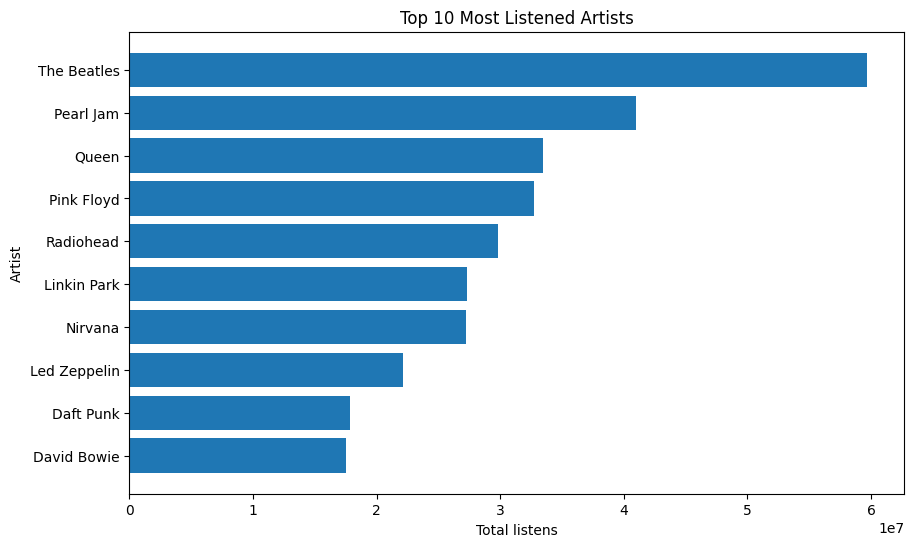

In [10]:
plt.figure(figsize=(10, 6))
plt.barh(top_artists["artist_name"], top_artists["total_listens"])
plt.xlabel("Total listens")
plt.ylabel("Artist")
plt.title("Top 10 Most Listened Artists")
plt.gca().invert_yaxis()
plt.show()


## 5. Which songs are most popular?

Tables used: `fact_listening_events`, `dim_track`


In [11]:
query_top_songs = f"""
SELECT
    t.track_name,
    t.artist_name,
    COUNT(*) AS total_listens
FROM `{PROJECT_ID}.{DATASET}.fact_listening_events` f
LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_track` t
    ON f.track_id = t.track_id
WHERE t.track_name IS NOT NULL
GROUP BY
    t.track_name,
    t.artist_name
ORDER BY total_listens DESC
LIMIT 10
"""

top_songs = run_query("top_songs", query_top_songs)
top_songs


Running query: top_songs
Saved: listenbrainz_analysis_outputs/top_songs.csv


,track_name,artist_name,total_listens
0,Even Flow,Pearl Jam,910283673
1,Alive,Pearl Jam,885378600
2,Black,Pearl Jam,634982562
3,Bohemian Rhapsody,Queen,406584752
4,Jeremy,Pearl Jam,393964263
5,Smells Like Teen Spirit,Nirvana,234252027
6,Stairway to Heaven,Led Zeppelin,227655816
7,Paranoid,Black Sabbath,224579520
8,Comfortably Numb,Pink Floyd,218795118
9,Love Will Tear Us Apart,Joy Division,196978320


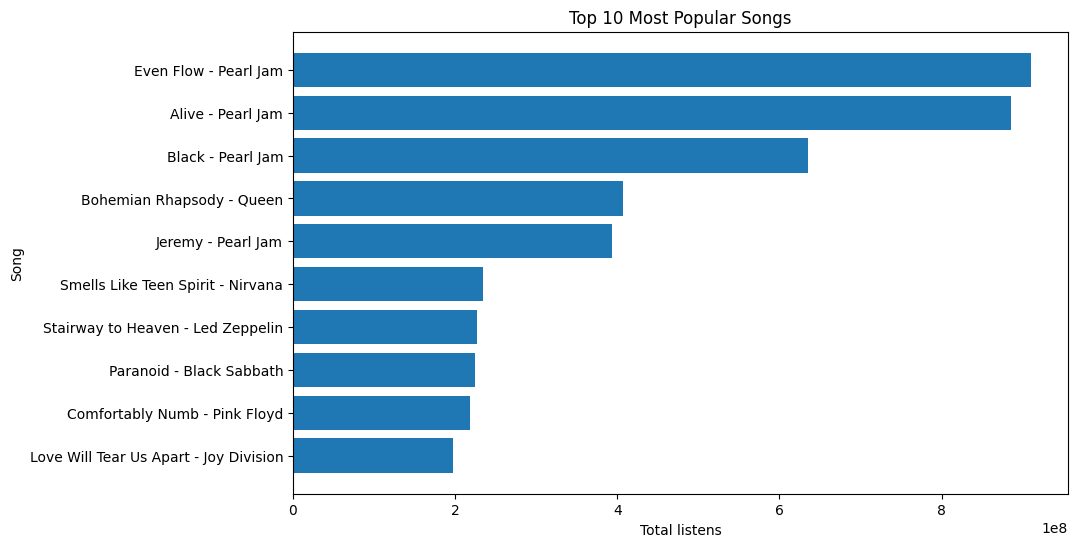

In [12]:
top_songs_plot = top_songs.copy()
top_songs_plot["song_label"] = top_songs_plot["track_name"] + " - " + top_songs_plot["artist_name"].fillna("Unknown")

plt.figure(figsize=(10, 6))
plt.barh(top_songs_plot["song_label"], top_songs_plot["total_listens"])
plt.xlabel("Total listens")
plt.ylabel("Song")
plt.title("Top 10 Most Popular Songs")
plt.gca().invert_yaxis()
plt.show()


## 6. What time of day do users listen most?

Tables used: `fact_listening_events`, `dim_time`


In [13]:
query_time_of_day = f"""
SELECT
    tm.time_period,
    COUNT(*) AS total_listens
FROM `{PROJECT_ID}.{DATASET}.fact_listening_events` f
LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_time` tm
    ON f.time_id = tm.time_id
WHERE tm.time_period IS NOT NULL
GROUP BY tm.time_period
ORDER BY total_listens DESC
"""

time_of_day = run_query("time_of_day", query_time_of_day)
time_of_day


Running query: time_of_day
Saved: listenbrainz_analysis_outputs/time_of_day.csv


,time_period,total_listens
0,Night,559712506
1,Afternoon,472387453
2,Morning,462264323
3,Evening,407823515


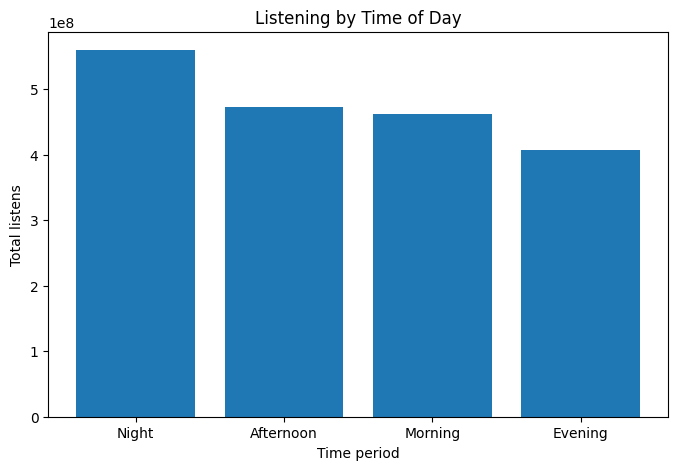

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(time_of_day["time_period"], time_of_day["total_listens"])
plt.xlabel("Time period")
plt.ylabel("Total listens")
plt.title("Listening by Time of Day")
plt.show()


## 7. Optional: Listening by hour

Tables used: `fact_listening_events`, `dim_time`


In [15]:
query_listens_by_hour = f"""
SELECT
    tm.hour,
    COUNT(*) AS total_listens
FROM `{PROJECT_ID}.{DATASET}.fact_listening_events` f
LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_time` tm
    ON f.time_id = tm.time_id
WHERE tm.hour IS NOT NULL
GROUP BY tm.hour
ORDER BY tm.hour
"""

listens_by_hour = run_query("listens_by_hour", query_listens_by_hour)
listens_by_hour


Running query: listens_by_hour
Saved: listenbrainz_analysis_outputs/listens_by_hour.csv


,hour,total_listens
0,0,74043338
1,1,61765167
2,2,57447599
3,3,54288629
4,4,52352808
5,5,52806078
6,6,55671526
7,7,59225837
8,8,64111316
9,9,69481504


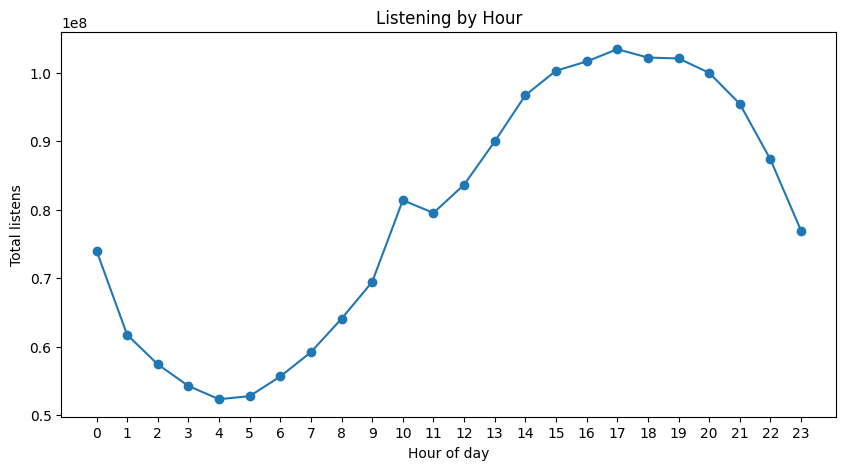

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(listens_by_hour["hour"], listens_by_hour["total_listens"], marker="o")
plt.xlabel("Hour of day")
plt.ylabel("Total listens")
plt.title("Listening by Hour")
plt.xticks(range(0, 24))
plt.show()


## 8. How does listening change monthly?

Tables used: `fact_listening_events`, `dim_date`


In [17]:
query_monthly_trend = f"""
SELECT
    d.year,
    d.month,
    COUNT(*) AS total_listens
FROM `{PROJECT_ID}.{DATASET}.fact_listening_events` f
LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_date` d
    ON f.date_id = d.date_id
WHERE d.year IS NOT NULL
  AND d.month IS NOT NULL
GROUP BY
    d.year,
    d.month
ORDER BY
    d.year,
    d.month
"""

monthly_trend = run_query("monthly_trend", query_monthly_trend)
monthly_trend


Running query: monthly_trend
Saved: listenbrainz_analysis_outputs/monthly_trend.csv


,year,month,total_listens
0,1970,1,5966978
1,1991,1,263
2,2000,1,9
3,2004,12,9
4,2005,2,10400253
...,...,...,...
161,2018,3,11183651
162,2018,4,8364512
163,2018,5,6622483
164,2018,6,4909963


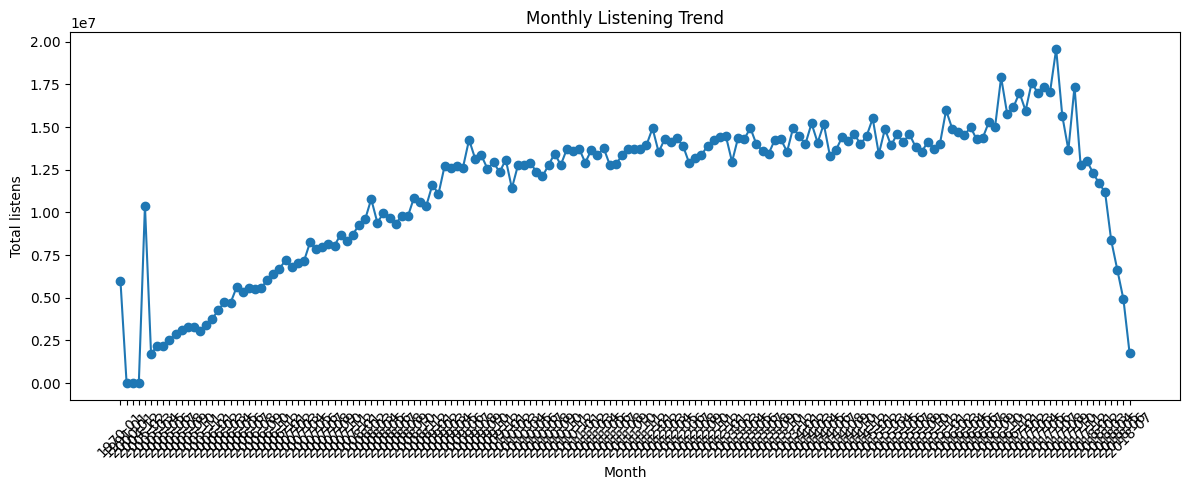

In [ ]:
monthly_trend_plot = monthly_trend.copy()

# Create proper month date
monthly_trend_plot["year_month_date"] = pd.to_datetime(
    monthly_trend_plot["year"].astype(str) + "-" +
    monthly_trend_plot["month"].astype(str).str.zfill(2) + "-01"
)

# Sort by month
monthly_trend_plot = monthly_trend_plot.sort_values("year_month_date")

# Keep only latest 24 months
monthly_trend_plot = monthly_trend_plot.tail(24)

# Create display label
monthly_trend_plot["year_month"] = monthly_trend_plot["year_month_date"].dt.strftime("%Y-%m")

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_trend_plot["year_month"],
    monthly_trend_plot["total_listens"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total listens")
plt.title("Monthly Listening Trend - Latest 24 Months")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Which users listen most often?

Tables used: `fact_listening_events`, `dim_user`


In [19]:
query_top_users = f"""
SELECT
    u.user_name,
    COUNT(*) AS total_listens
FROM `{PROJECT_ID}.{DATASET}.fact_listening_events` f
LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_user` u
    ON f.user_id = u.user_id
WHERE u.user_name IS NOT NULL
GROUP BY u.user_name
ORDER BY total_listens DESC
LIMIT 10
"""

top_users = run_query("top_users", query_top_users)
top_users


Running query: top_users
Saved: listenbrainz_analysis_outputs/top_users.csv


,user_name,total_listens
0,CatCat,20223962
1,gbcox,19537682
2,lb_test_1,18968040
3,dak180,14390874
4,Teknojnky,14311582
5,erzengel11,11582380
6,gbooker,11375943
7,nayTuHbl4,9549082
8,Dale Coop,9547147
9,enkadeze,8735549


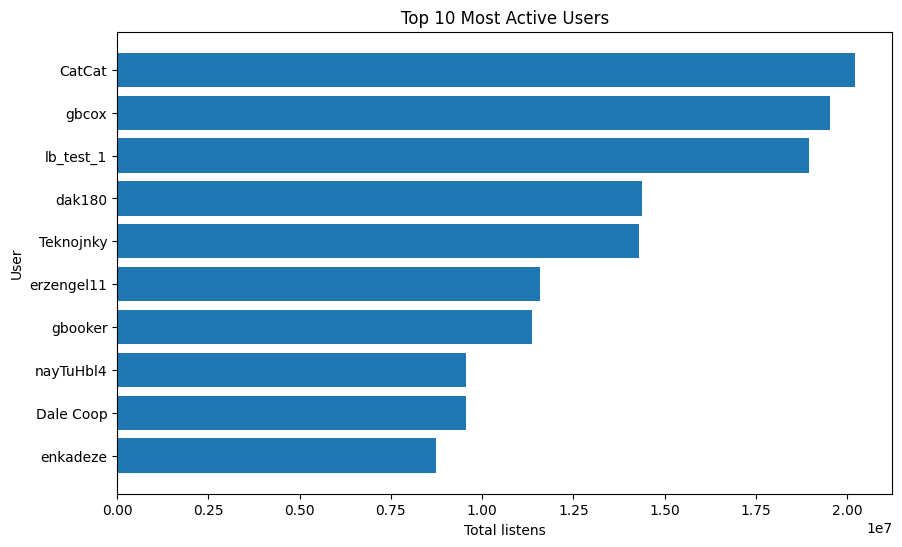

In [20]:
plt.figure(figsize=(10, 6))
plt.barh(top_users["user_name"], top_users["total_listens"])
plt.xlabel("Total listens")
plt.ylabel("User")
plt.title("Top 10 Most Active Users")
plt.gca().invert_yaxis()
plt.show()


## 10. Which albums / releases are trending?

Tables used: `fact_listening_events`, `dim_album`

Note: Your source dataset uses `release_name`. In the star schema, `dim_album.album_name` is aliased back to `release_name`.


In [22]:
query_top_releases = f"""
SELECT
    al.release_name,
    al.artist_name,
    COUNT(*) AS total_listens
FROM `{PROJECT_ID}.{DATASET}.fact_listening_events` f
LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_album` al
    ON f.album_id = al.album_id
WHERE al.release_name IS NOT NULL
GROUP BY
    al.release_name,
    al.artist_name
ORDER BY total_listens DESC
LIMIT 10
"""

top_releases = run_query("top_releases", query_top_releases)
top_releases


Running query: top_releases
Saved: listenbrainz_analysis_outputs/top_releases.csv


,release_name,artist_name,total_listens
0,,The Beatles,41443707
1,,Pearl Jam,26715660
2,,Queen,26158848
3,,Pink Floyd,24917726
4,,Radiohead,22559740
5,,Nirvana,19999035
6,,Linkin Park,19980720
7,,Led Zeppelin,17636562
8,,David Bowie,13427319
9,,Nine Inch Nails,12878175


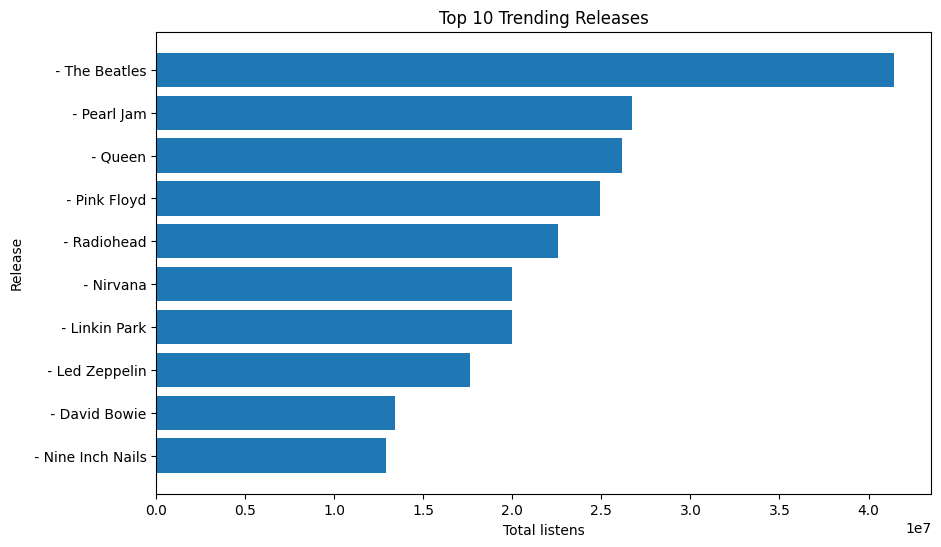

In [23]:
top_releases_plot = top_releases.copy()
top_releases_plot["release_label"] = top_releases_plot["release_name"] + " - " + top_releases_plot["artist_name"].fillna("Unknown")

plt.figure(figsize=(10, 6))
plt.barh(top_releases_plot["release_label"], top_releases_plot["total_listens"])
plt.xlabel("Total listens")
plt.ylabel("Release")
plt.title("Top 10 Trending Releases")
plt.gca().invert_yaxis()
plt.show()


## 11. Summary for report

Python was used to query the ListenBrainz star schema in BigQuery. The analysis joined the central `fact_listening_events` table with dimension tables including `dim_artist`, `dim_track`, `dim_time`, `dim_date`, `dim_user`, and `dim_album`. These queries answered key business questions such as the most listened artists, popular songs, peak listening periods, monthly listening trends, most active users, and trending releases. The outputs were exported to CSV files for reporting and visualisation.
